# Importing libraries📚

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
import pandas as pd
%matplotlib inline

# Getting data 💽

In [2]:
train = pd.read_csv("../input/digit-recognizer/train.csv",dtype = np.float32)
test = pd.read_csv("../input/digit-recognizer/test.csv",dtype = np.float32)

In [3]:
print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


### There are 42,000 images in training set. We'll use 90% of the training set for training and 10% data for validation

In [4]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
targets = train.label.values # 1st column that is values
features = train.drop(labels = ["label"],axis = 1).values / 255 #normalize

### Converting the pandas dataframe to numpy array to later covert into pytorch tensors ⚙️🛠️

In [7]:
targetsTrain = torch.from_numpy(targets).type(torch.LongTensor)
featuresTrain = torch.from_numpy(features)

In [8]:
trn = torch.utils.data.TensorDataset(featuresTrain,targetsTrain)

In [9]:
val_size = 4200
train_size = len(trn) - val_size

train_ds, val_ds = random_split(trn, [train_size, val_size])
len(train_ds), len(val_ds)

(37800, 4200)

In [10]:
batch_size = 256

In [11]:
train_loader = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)

# Viewing some training images 🤳

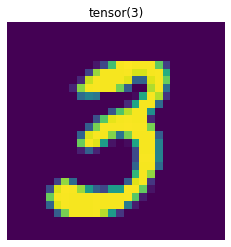

In [12]:
for images,labels in train_loader:
    plt.imshow(images[28].reshape(28,28))
    plt.axis("off")
    plt.title(str(labels[28]))
    plt.show()
    break

# Now we view a batch of training images 📈🤳

images.shape: torch.Size([256, 784])


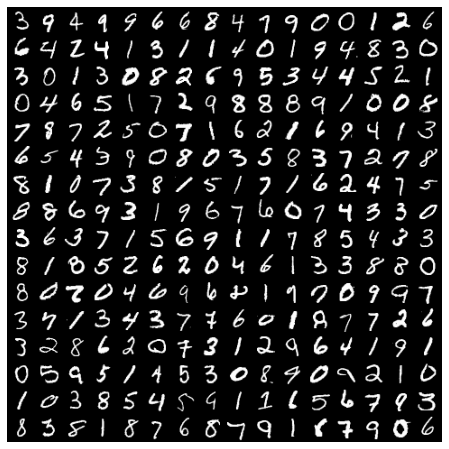

In [13]:
for images, _ in train_loader:
    imgs = []
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,8))
    for img in images:
        im = img.reshape(28,28)
        im = im.view(-1,im.size(0),im.size(1))
        imgs.append(im)
        plt.axis('off')
    plt.imshow(make_grid(imgs, nrow=16).permute((1,2,0)))
    break

Defining function to calculate model accuracy for user. This won't help in training as it is not a differentiable function 

In [14]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

# Creating a Simple PyTorch Model  🧩🧩
### Defining a model with 1 input + 2 hidden layers 

In [15]:
class Mnistnn(nn.Module):
    def __init__(self,in_size,hidden_size1,hidden_size2,hidden_size3,out_size):
        super().__init__()
        self.linear1 = nn.Linear(in_size, hidden_size1)
        self.linear2 = nn.Linear(hidden_size1, hidden_size2)
        self.linear3 = nn.Linear(hidden_size2,hidden_size3)
        self.linear4 = nn.Linear(hidden_size3,out_size)
    
    def forward(self,xb):
        #xb.size(0) will be the batch size(change dynamically)
        # -1 ths will be calculate by pytorch itself..
        xb = xb.view(-1,xb.size(1))
        out = self.linear1(xb)
        out = F.relu(out)
        out = self.linear2(out)
        out = F.relu(out)
        out = self.linear3(out)
        out = F.relu(out)
        out = self.linear4(out)
        out = F.relu(out)
        return out
    
    def training_step(self,batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out,labels)
        return loss
    
    def validation_step(self,batch):
        images,labels = batch
        out = self(images)
        loss = F.cross_entropy(out,labels)
        acc = accuracy(out,labels)
        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self,outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self,epoch,result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

In [16]:
input_size = 784
hidden_size1 = 512
hidden_size2 = 256
hidden_size3 = 64
num_classes = 10

In [17]:
model = Mnistnn(input_size, hidden_size1=hidden_size1, hidden_size2= hidden_size2,hidden_size3 = hidden_size3, out_size=num_classes)

In [18]:
for t in model.parameters():
    print(t.shape)

torch.Size([512, 784])
torch.Size([512])
torch.Size([256, 512])
torch.Size([256])
torch.Size([64, 256])
torch.Size([64])
torch.Size([10, 64])
torch.Size([10])


## Intial loss with random weights 📉

In [19]:
for images, labels in train_loader:
    outputs = model(images)
    print(labels.shape)
    loss = F.cross_entropy(outputs, labels)
    print('Loss:', loss.item())
    break

print('outputs.shape : ', outputs.shape)
print('Sample outputs :\n', outputs[:2].data)

torch.Size([256])
Loss: 2.3071372509002686
outputs.shape :  torch.Size([256, 10])
Sample outputs :
 tensor([[0.1190, 0.0090, 0.0000, 0.0173, 0.0377, 0.0000, 0.0495, 0.0000, 0.0707,
         0.0000],
        [0.1191, 0.0041, 0.0000, 0.0234, 0.0337, 0.0000, 0.0417, 0.0000, 0.0604,
         0.0000]])


# Using GPU for Training ❤️🔥 

In [20]:
torch.cuda.is_available()

True

In [21]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

In [22]:
device = get_default_device()
device

device(type='cuda')

In [23]:
# Moving PyTorch Tensors to GPU
def to_device(data, device):
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [24]:
for images, labels in train_loader:
    print(images.shape)
    images = to_device(images, device)
    print(images.device)
    break

torch.Size([256, 784])
cuda:0


In [25]:
class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [26]:
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

In [27]:
for xb, yb in val_loader:
    print('xb.device:', xb.device)
    print('yb:', yb)
    break

xb.device: cuda:0
yb: tensor([6, 8, 9, 9, 4, 8, 4, 3, 7, 3, 8, 7, 9, 1, 6, 1, 1, 8, 0, 3, 9, 3, 8, 8,
        6, 6, 7, 2, 5, 3, 1, 7, 9, 8, 8, 9, 2, 0, 4, 7, 8, 9, 3, 1, 7, 1, 5, 0,
        0, 3, 0, 7, 4, 7, 6, 4, 1, 9, 2, 7, 8, 0, 2, 2, 6, 8, 4, 1, 0, 8, 5, 7,
        6, 4, 5, 3, 5, 4, 0, 5, 9, 8, 5, 7, 3, 9, 8, 1, 5, 8, 7, 7, 7, 0, 1, 4,
        5, 0, 7, 3, 6, 3, 1, 5, 9, 2, 1, 4, 2, 5, 8, 1, 2, 1, 6, 3, 1, 5, 8, 2,
        1, 9, 8, 5, 7, 8, 1, 3, 7, 0, 2, 9, 1, 2, 3, 1, 1, 8, 6, 3, 4, 1, 4, 3,
        9, 7, 7, 5, 7, 7, 9, 1, 8, 3, 3, 7, 5, 7, 2, 7, 3, 7, 7, 2, 4, 7, 9, 2,
        5, 9, 0, 1, 8, 7, 0, 3, 1, 0, 1, 1, 3, 9, 1, 5, 0, 0, 9, 7, 9, 1, 1, 6,
        0, 7, 3, 3, 3, 8, 7, 7, 3, 3, 7, 4, 3, 2, 4, 6, 2, 8, 1, 4, 5, 4, 2, 3,
        8, 2, 6, 9, 6, 8, 7, 7, 7, 1, 2, 1, 4, 9, 5, 6, 2, 4, 6, 0, 6, 3, 9, 4,
        2, 6, 3, 2, 2, 2, 2, 5, 3, 9, 3, 4, 1, 8, 7, 9, 2, 1, 6, 9, 7, 1, 1, 7,
        1, 4, 6, 9, 9, 6, 1, 5, 6, 3, 7, 9, 1, 5, 3, 4, 0, 1, 1, 0, 1, 6, 3, 5,
        6, 8, 9, 9

Defining Evaluate function and training loop for our model

In [28]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    time = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        time.append(result)
    return time

### Create model on GPU

In [29]:
model = Mnistnn(input_size, hidden_size1=hidden_size1, hidden_size2= hidden_size2, hidden_size3= hidden_size3, out_size=num_classes)
to_device(model, device)

Mnistnn(
  (linear1): Linear(in_features=784, out_features=512, bias=True)
  (linear2): Linear(in_features=512, out_features=256, bias=True)
  (linear3): Linear(in_features=256, out_features=64, bias=True)
  (linear4): Linear(in_features=64, out_features=10, bias=True)
)

In [30]:
time = [evaluate(model, val_loader)]
time

[{'val_loss': 2.3024487495422363, 'val_acc': 0.1037493348121643}]

#### We only get around 9-15% accuracy. Which is okay considering random initailization of weights... But now we train the model

In [31]:
time += fit(10, 0.5, model, train_loader, val_loader) #Learning Rate = 0.5

Epoch [0], val_loss: 0.3651, val_acc: 0.8923
Epoch [1], val_loss: 0.1947, val_acc: 0.9413
Epoch [2], val_loss: 0.1564, val_acc: 0.9528
Epoch [3], val_loss: 0.1261, val_acc: 0.9600
Epoch [4], val_loss: 0.1598, val_acc: 0.9526
Epoch [5], val_loss: 0.1109, val_acc: 0.9649
Epoch [6], val_loss: 0.1006, val_acc: 0.9663
Epoch [7], val_loss: 0.0977, val_acc: 0.9719
Epoch [8], val_loss: 0.0896, val_acc: 0.9740
Epoch [9], val_loss: 848.6740, val_acc: 0.1107


In [32]:
time += fit(16, 0.2, model, train_loader, val_loader)

Epoch [0], val_loss: 1.8841, val_acc: 0.3127
Epoch [1], val_loss: 1.6845, val_acc: 0.4253
Epoch [2], val_loss: 1.4546, val_acc: 0.5364
Epoch [3], val_loss: 1.2308, val_acc: 0.6057
Epoch [4], val_loss: 0.8987, val_acc: 0.7255
Epoch [5], val_loss: 0.8769, val_acc: 0.7414
Epoch [6], val_loss: 0.8617, val_acc: 0.7533
Epoch [7], val_loss: 0.8516, val_acc: 0.7559
Epoch [8], val_loss: 0.7002, val_acc: 0.7957
Epoch [9], val_loss: 0.6432, val_acc: 0.8410
Epoch [10], val_loss: 0.6407, val_acc: 0.8341
Epoch [11], val_loss: 0.6268, val_acc: 0.8380
Epoch [12], val_loss: 0.6057, val_acc: 0.8521
Epoch [13], val_loss: 0.5961, val_acc: 0.8556
Epoch [14], val_loss: 0.5923, val_acc: 0.8604
Epoch [15], val_loss: 0.5775, val_acc: 0.8633


In [33]:
time += fit(16, 0.0001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.5769, val_acc: 0.8636
Epoch [1], val_loss: 0.5764, val_acc: 0.8633
Epoch [2], val_loss: 0.5760, val_acc: 0.8627
Epoch [3], val_loss: 0.5756, val_acc: 0.8625
Epoch [4], val_loss: 0.5752, val_acc: 0.8623
Epoch [5], val_loss: 0.5748, val_acc: 0.8616
Epoch [6], val_loss: 0.5745, val_acc: 0.8614
Epoch [7], val_loss: 0.5742, val_acc: 0.8616
Epoch [8], val_loss: 0.5739, val_acc: 0.8616
Epoch [9], val_loss: 0.5737, val_acc: 0.8618
Epoch [10], val_loss: 0.5735, val_acc: 0.8620
Epoch [11], val_loss: 0.5733, val_acc: 0.8623
Epoch [12], val_loss: 0.5731, val_acc: 0.8620
Epoch [13], val_loss: 0.5729, val_acc: 0.8623
Epoch [14], val_loss: 0.5727, val_acc: 0.8620
Epoch [15], val_loss: 0.5725, val_acc: 0.8623


In [34]:
time += fit(100, 0.00001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.5725, val_acc: 0.8623
Epoch [1], val_loss: 0.5725, val_acc: 0.8623
Epoch [2], val_loss: 0.5725, val_acc: 0.8623
Epoch [3], val_loss: 0.5725, val_acc: 0.8623
Epoch [4], val_loss: 0.5725, val_acc: 0.8623
Epoch [5], val_loss: 0.5724, val_acc: 0.8623
Epoch [6], val_loss: 0.5724, val_acc: 0.8623
Epoch [7], val_loss: 0.5724, val_acc: 0.8623
Epoch [8], val_loss: 0.5724, val_acc: 0.8623
Epoch [9], val_loss: 0.5724, val_acc: 0.8623
Epoch [10], val_loss: 0.5724, val_acc: 0.8623
Epoch [11], val_loss: 0.5724, val_acc: 0.8623
Epoch [12], val_loss: 0.5723, val_acc: 0.8623
Epoch [13], val_loss: 0.5723, val_acc: 0.8623
Epoch [14], val_loss: 0.5723, val_acc: 0.8620
Epoch [15], val_loss: 0.5723, val_acc: 0.8620
Epoch [16], val_loss: 0.5723, val_acc: 0.8620
Epoch [17], val_loss: 0.5723, val_acc: 0.8620
Epoch [18], val_loss: 0.5722, val_acc: 0.8620
Epoch [19], val_loss: 0.5722, val_acc: 0.8620
Epoch [20], val_loss: 0.5722, val_acc: 0.8620
Epoch [21], val_loss: 0.5722, val_acc: 0.862

## Viewing loss over epochs 📉
### we see it drops quickly at first.. then it slows down

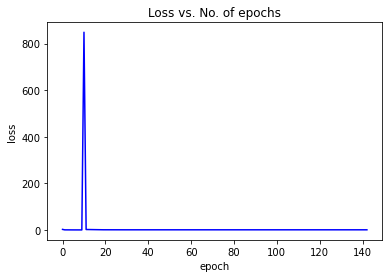

In [35]:
losses = [x['val_loss'] for x in time]
plt.plot(losses, '-b')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss vs. No. of epochs');

## Viewing accuracies increase over epochs 📈
### we see accuracy of our model rise as it trains

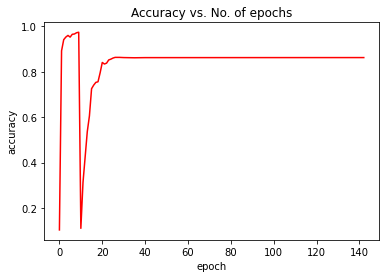

In [36]:
accuracies = [x['val_acc'] for x in time]
plt.plot(accuracies, 'r-')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs. No. of epochs');

# Now we predict the Test Set 💾

In [37]:
features_test = test.values / 255
features_tensor = torch.from_numpy(features_test)
test_loader = DataLoader(features_tensor, batch_size*2, num_workers=4, pin_memory=True)

In [38]:
# Prediction Function
def predict(tl, model):
    preds = torch.cuda.LongTensor()
    for img in tl:
        y = model(img)
        _, pred  = torch.max(y, dim=1)
        preds = torch.cat((preds, pred), dim=0)
    return preds

## Visualizing Test Set 🏷️

images.shape: torch.Size([512, 784])


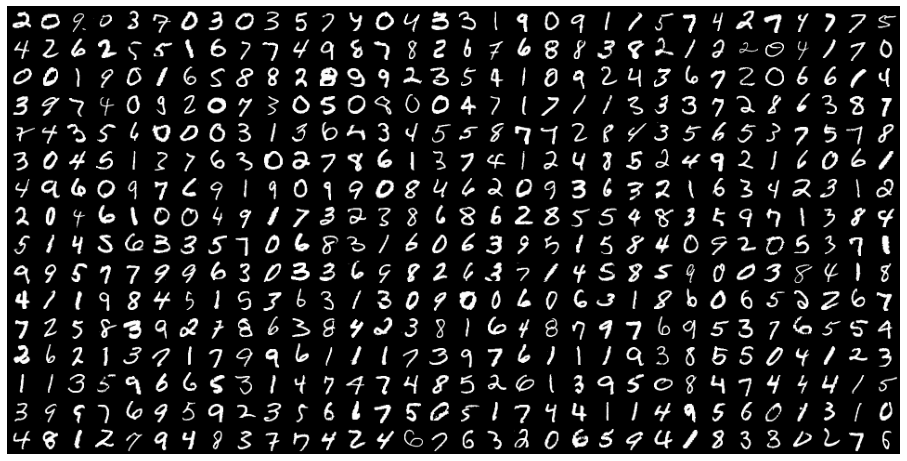

In [39]:
for images in test_loader:
    imgs = []
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,9))
    for img in images:
        im = img.reshape(28,28)
        im = im.view(-1,im.size(0),im.size(1))
        imgs.append(im)
        plt.axis('off')
    plt.imshow(make_grid(imgs, nrow=32).permute((1,2,0)))
    break

# Submission 📝

In [40]:
test_loader_gpu = DeviceDataLoader(test_loader, device)

In [41]:
test_preds = predict(test_loader_gpu,model)

In [42]:
test_predictions = test_preds.cpu()

In [43]:
test_df = pd.DataFrame(np.c_[np.arange(1, len(test)+1), test_predictions.numpy()], 
                      columns=['ImageId', 'Label'])

In [44]:
test_df.to_csv('submission.csv', index=False)

In [45]:
test_df.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
